In [1]:
import subprocess
subprocess.run(['pip', 'install', 'nltk', '-q'])

import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [2]:
import pandas as pd

data = {
    'ticket_id': range(1, 11),
    'ticket_text': [
        "My payment failed and I was charged twice",
        "I cannot login to my account, password not working",
        "The app keeps crashing on my phone",
        "I need a refund for my last order",
        "Server is down and I cannot access my files",
        "How do I upgrade my subscription plan",
        "My account got hacked, please help urgently",
        "The website is very slow today",
        "I was billed the wrong amount this month",
        "How do I cancel my subscription"
    ],
    'category': [
        'Billing', 'Account', 'Technical', 'Billing',
        'Technical', 'Account', 'Account', 'Technical',
        'Billing', 'Account'
    ]
}

df = pd.DataFrame(data)
print(df)

   ticket_id                                        ticket_text   category
0          1          My payment failed and I was charged twice    Billing
1          2  I cannot login to my account, password not wor...    Account
2          3                 The app keeps crashing on my phone  Technical
3          4                  I need a refund for my last order    Billing
4          5        Server is down and I cannot access my files  Technical
5          6              How do I upgrade my subscription plan    Account
6          7        My account got hacked, please help urgently    Account
7          8                     The website is very slow today  Technical
8          9           I was billed the wrong amount this month    Billing
9         10                    How do I cancel my subscription    Account


In [3]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

df['clean_text'] = df['ticket_text'].apply(clean_text)
print(df[['ticket_text', 'clean_text']])

                                         ticket_text  \
0          My payment failed and I was charged twice   
1  I cannot login to my account, password not wor...   
2                 The app keeps crashing on my phone   
3                  I need a refund for my last order   
4        Server is down and I cannot access my files   
5              How do I upgrade my subscription plan   
6        My account got hacked, please help urgently   
7                     The website is very slow today   
8           I was billed the wrong amount this month   
9                    How do I cancel my subscription   

                                clean_text  
0             payment failed charged twice  
1    cannot login account password working  
2                 app keeps crashing phone  
3                   need refund last order  
4               server cannot access files  
5                upgrade subscription plan  
6  account got hacked please help urgently  
7                      

Classification Report:
              precision    recall  f1-score   support

     Account       0.43      0.75      0.55         4
     Billing       0.00      0.00      0.00         3
   Technical       0.33      0.33      0.33         3

    accuracy                           0.40        10
   macro avg       0.25      0.36      0.29        10
weighted avg       0.27      0.40      0.32        10

Overall Accuracy: 40.0%


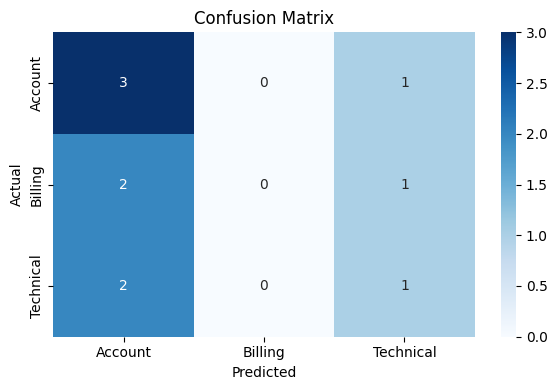

MultinomialNB()

In [9]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# FIX 1: With only 10 samples, train_test_split is unreliable.
# Use cross-validation instead to get meaningful metrics.
model = MultinomialNB()

# FIX: Reduced n_splits to 3 because the smallest class (Billing/Technical) has 3 members.
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
predictions = cross_val_predict(model, X, y, cv=cv)

# Print metrics
print("Classification Report:")
print(classification_report(y, predictions, zero_division=0))
print(f"Overall Accuracy: {accuracy_score(y, predictions) * 100:.1f}%")

# Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y, predictions, labels=['Account', 'Billing', 'Technical'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Account', 'Billing', 'Technical'],
            yticklabels=['Account', 'Billing', 'Technical'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# Also fit on full data so model is ready for Cell 5 onwards
model.fit(X, y)

In [6]:
def assign_priority(text):
    text = text.lower()
    high_keywords = ['hacked', 'server down', 'charged twice', 'urgently', 'cannot access']
    medium_keywords = ['refund', 'billing', 'wrong amount', 'failed']

    if any(word in text for word in high_keywords):
        return 'High'
    elif any(word in text for word in medium_keywords):
        return 'Medium'
    else:
        return 'Low'

df['priority'] = df['ticket_text'].apply(assign_priority)
print(df[['ticket_text', 'category', 'priority']])

                                         ticket_text   category priority
0          My payment failed and I was charged twice    Billing     High
1  I cannot login to my account, password not wor...    Account      Low
2                 The app keeps crashing on my phone  Technical      Low
3                  I need a refund for my last order    Billing   Medium
4        Server is down and I cannot access my files  Technical     High
5              How do I upgrade my subscription plan    Account      Low
6        My account got hacked, please help urgently    Account     High
7                     The website is very slow today  Technical      Low
8           I was billed the wrong amount this month    Billing   Medium
9                    How do I cancel my subscription    Account      Low


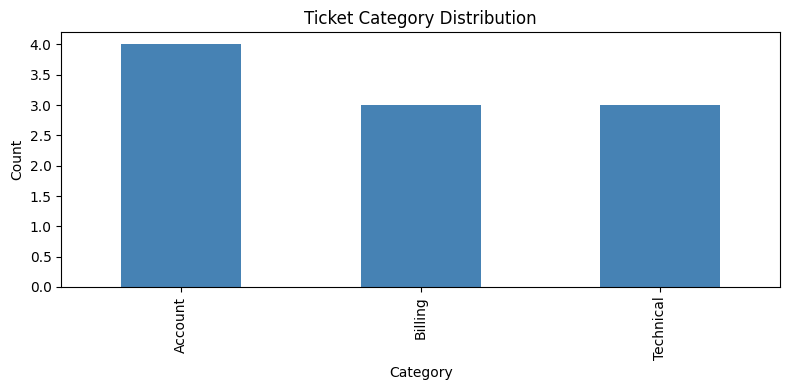

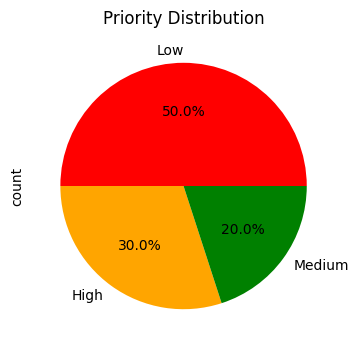

In [7]:
import matplotlib.pyplot as plt

# Category distribution
plt.figure(figsize=(8, 4))
df['category'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Ticket Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('category_distribution.png')
plt.show()

# Priority distribution
plt.figure(figsize=(6, 4))
df['priority'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['red','orange','green'])
plt.title('Priority Distribution')
plt.savefig('priority_distribution.png')
plt.show()